<a href="https://colab.research.google.com/github/reddolivia/peumoniaMNIST/blob/main/pneumoniaMNIST1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# install the medmnist pakages - gives the access to PneumoniaMNIST and other medical dataset

!pip install medmnist -q

In [13]:
# core imports; numpy for arays, torch for building and training models
#               dataloader for batching data, transform for preprocessing images
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from  torch.utils.data import DataLoader
import torchvision.transforms as transforms
from medmnist import PneumoniaMNIST




In [14]:
# Use GPU if colab gives us one, otherwise fallback on CPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)

device cpu


In [15]:
# preprocessing: converts images to tensors, then normalize the pixel values
#                to roughly [-1,1] - helps the model train faster and more stable

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean =[0.5], std = [0.5])
])

In [16]:
# load the three splits: trains-to learn, val- to check progress,
#                       test- final unseen     // download = True (grabs the dat automatically)

train_dataset = PneumoniaMNIST(split ='train', transform = data_transform, download = True )
val_dataset = PneumoniaMNIST(split='val', transform = data_transform, download=True)
test_dataset = PneumoniaMNIST(split = 'test', transform = data_transform,download=True)

In [17]:
# sanity check - confirm how many iamges are in each split
print(f"train:{len(train_dataset)} | val: {len(val_dataset)}  | test: {len(test_dataset)}")

train:4708 | val: 524  | test: 624


In [18]:
# wrap each dataset in DataLoader - batches of   64 images at a time
# shuffled for training so the model doestn't memorise the order

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle =False)

In [19]:
from torch.nn.modules import padding
# define the CNN Archiecture  this is the "brain" that learns to spot peumonoia

class PeumoniaCNN(nn.Module):
  def __init__(self):
    super().__init__()

    # feature extraction: Scans the Images for patterns (edges, textures, shapes)
    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),    # 1 Grayscale channel in , 16 filters out
        nn.ReLU(),                                     # adds non-linearity to model can learn complex patterns
        nn.MaxPool2d(2),                               #shrinks the images size 28 -> 14 keeps strongest features
        nn.Conv2d(16, 32, kernel_size= 3, padding= 1), # deepens the network 16 filterns in, 32 out
        nn.ReLU(),
        nn.MaxPool2d(2)                                # shrinks again 14 -> 7

    )


    # classifier:  Takes the extracted features ansd decide normal vs peumonia
    self.classifier = nn.Sequential(
        nn.Flatten(),                   # falttens 3D features map -> 1D list
        nn.Linear(32*7*7, 64),          # fully connected layer, compress down to 64 values
        nn.Dropout(0.3),                # randomly drops 30% of neurons during training- prevents overfitting
        nn.Linear(64,1)                 # final output: one number (higher = more likely peumonia)

    )


  def forward(self, x):
    # defines  how data flows through model: images -> features -> classifier -> predictions
    x = self.features(x)
    x = self.classifier(x)

    return x

model = PeumoniaCNN().to(device)
print(model)

# quick check - how many learnalbe parameters(weights) does this model have ?
print('total params:', sum(p.numel() for p in model.parameters()))


PeumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
total params: 105281


In [26]:
import time

# loss function: measures how wrong the model's predictions are (for binary yes/no problems)
criterion = nn.BCEWithLogitsLoss()

# optimizer: updates the model's weights to reduce that loss over time
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# how many times we loop through the entire training set
EPOCHS = 10
start_time = time.time()

for epoch in range(EPOCHS):
    # --- training phase ---
    model.train()  # puts the model in "learning mode" (dropout is active)
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()                            # clear old gradients from the last batch
        outputs = model(images).squeeze(1)               # run the images through the model
        loss = criterion(outputs, labels.squeeze(1))     # compare prediction vs actual label
        loss.backward()                                  # calculate how to adjust the weights
        optimizer.step()                                 # actually update the weights
        running_loss += loss.item()                      # track loss for this batch

    # --- validation phase ---
    model.eval()  # puts the model in "testing mode" (dropout turned off)
    correct, total = 0, 0

    with torch.no_grad():  # no need to track gradients here, we're just checking accuracy
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().squeeze(1)
            outputs = torch.sigmoid(model(images).squeeze(1))   # sigmoid converts raw output to a 0-1 probability
            preds = (outputs > 0.5).float()                     # above 0.5 = predict pneumonia
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # print progress after each epoch — watch the accuracy climb as training goes
    print(f'epoch {epoch+1}/{EPOCHS} | loss: {running_loss/len(train_loader):.4f} | val acc: {100*correct/total:.2f}%')

elapsed = time.time() - start_time

# total time spent training — good for your "took X minutes" line in the video
print(f'\ntraining time: {elapsed/60:.1f}')

epoch 1/10 | loss: 0.1004 | val acc: 95.42%
epoch 2/10 | loss: 0.0962 | val acc: 96.76%
epoch 3/10 | loss: 0.0860 | val acc: 96.37%
epoch 4/10 | loss: 0.0769 | val acc: 97.14%
epoch 5/10 | loss: 0.0780 | val acc: 96.76%
epoch 6/10 | loss: 0.0662 | val acc: 96.76%
epoch 7/10 | loss: 0.0632 | val acc: 96.76%
epoch 8/10 | loss: 0.0637 | val acc: 96.95%
epoch 9/10 | loss: 0.0508 | val acc: 97.52%
epoch 10/10 | loss: 0.0478 | val acc: 95.99%

training time: 0.8


In [27]:
# switch to evaluation mode - turns off fropout so predictions are consistent
model.eval()

correct, total = 0,0

# no gradient tracking here - were judy measuring accuracy, not training
with torch.no_grad():
  for images , labels in test_loader:
    images = images.to(device)
    labels = labels.to(device).float().squeeze(1)

    outputs = torch.sigmoid(model(images).squeeze(1))   # convert raw output to 0-1 probability
    preds = (outputs > 0.5).float()                     # above 0.5 = predict pneumonia

    correct += (preds == labels).sum().item()           # count how many predictions matched the true label
    total   += labels.size(0)

# this is the real, unbiased accuracy number =  the test set was never seen during trainig
test_acc = 100*correct/total
print(f"FINAL TEST ACCURACY: {test_acc:.2f}")

FINAL TEST ACCURACY: 79.65


In [28]:
# save the models learned weights ( not the whole architecture) to the file

torch.save(model.state_dict(), 'pneumonia_cnn.pth')
print("saved peumonia_model.pth")

# trigger a browser download so the file lands on on your actual comp
# you'll need this file ;ater to plugg into your apps backend
from google.colab import files
files.download('pneumonia_cnn.pth')

saved peumonia_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

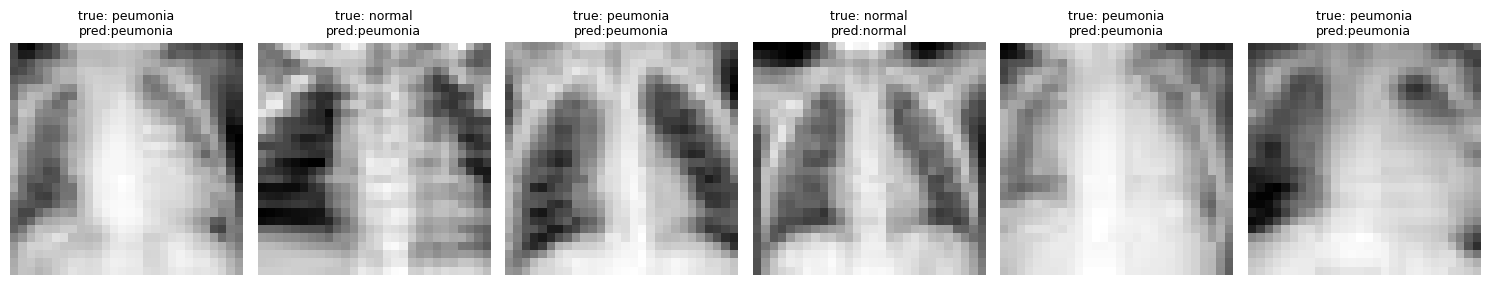

In [31]:
import matplotlib.pyplot as plt

# grab one batch of test images to visualize  - next(iter(....)) pulls the first batch
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

# run predictions on this batch, no need to track gradients since we're not training
with torch.no_grad():
  preds = torch.sigmoid(model(images_gpu).squeeze(1)) > 0.5    # True = predicted peumonia

# set up row of 6 side-by-side images
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
  img = images[i][0].numpy()     # put raw images to display
  true_label = 'peumonia' if labels[i].item() == 1 else 'normal'    # real, correct ans
  pred_label = 'peumonia' if preds[i].item() == 1 else 'normal'    # whar the model guessed

  ax.imshow(img, cmap='gray')                                       # show the x-ray
  ax.set_title(f"true: {true_label}\npred:{pred_label}", fontsize=9)          # label with real vs predicted
  ax.axis('off')

plt.tight_layout()
plt.savefig('sample_preds.png', dpi= 150) # saves the images file - good for screen recording/slides
plt.show()

In [32]:
# ---------------------------------------------------------
# WANT TO PUSH ACCURACY HIGHER? try these, one at a time:
# ---------------------------------------------------------

# 1. train for more epochs
#    change EPOCHS = 10 to EPOCHS = 20 or 30 in the training cell
#    more passes over the data = more chances to learn patterns
#    (watch for the val accuracy plateauing — that's when to stop)

# 2. add data augmentation
#    randomly flip/rotate/shift training images slightly so the model
#    sees more variation and doesn't just memorize the training set
#    example: add transforms.RandomHorizontalFlip() to data_transform

# 3. go deeper — add another conv layer
#    one more nn.Conv2d + nn.ReLU + nn.MaxPool2d block in self.features
#    lets the model learn more complex patterns (but risks overfitting
#    on a small dataset, so watch val accuracy closely)

# 4. lower the learning rate
#    change lr=1e-3 to lr=5e-4 in the optimizer
#    smaller steps = more precise learning, especially in later epochs

# 5. try class weighting
#    if pneumonia/normal images aren't evenly split, the model can get
#    lazy and just guess the majority class — check your class balance
#    and add pos_weight to BCEWithLogitsLoss if it's skewed

# 6. use a pretrained model instead of training from scratch
#    swap this custom CNN for a pretrained one like ResNet18, fine-tuned
#    on this dataset — usually the single biggest accuracy jump, but
#    also the most advanced option here